In [63]:
import os
import math
import time
import random
import csv
from typing import Tuple, Dict, List, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu126
torchvision: 0.25.0+cu126


In [64]:

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False
DATA_DIR = "./data"

BATCH_SIZE = 64 if DEVICE.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2
EPOCHS = 4 if FAST_MODE else 12
IMG_SIZE = 224

Device: cuda


In [65]:

STL10_MEAN = (0.4914, 0.4822, 0.4465)
STL10_STD  = (0.2023, 0.1994, 0.2010)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

class SubsetWithTransform(Dataset):
    """
    Независимый Dataset, который применяет указанный transform к выборке по индексам.
    Гарантирует, что transform выполнится независимо от настроек исходного датасета.
    """
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        # Получаем оригинальные данные по индексу из исходного датасета
        img, target = self.dataset[self.indices[idx]]
        # Применяем трансформ, если он задан
        if self.transform is not None:
            img = self.transform(img)
        return img, target

    def __len__(self):
        return len(self.indices)


def load_stl10(mode: str, data_dir: str = DATA_DIR, test_ratio: float = 0.2, val_ratio: float = 0.2, seed=RANDOM_STATE):
    """
    Загружает STL10 и возвращает сплиты (train, val, test) с трансформами в зависимости от mode.
    
    Args:
        mode (str): 'base' (только нормализация), 
                    'aug' (аугментации для train, нормализация для val/test), 
                    'resnet' (подготовка для pretrained ResNet).
    """
    
    transform_base = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    transform_aug = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(96, scale=(0.7, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    transform_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

    # скачиваем датасет один раз, а затем применяем нужный transform через класс SubsetWithTransform
    ds_full = torchvision.datasets.STL10(root=data_dir, split='train', download=True, transform=None)

    # 3. Разделение на сплиты (получаем индексы)
    total_size = len(ds_full)
    test_size = int(total_size * test_ratio)
    val_size = int(total_size * val_ratio)
    train_size = total_size - val_size - test_size

    gen = torch.Generator().manual_seed(seed)
    train_subset, val_subset, test_subset = random_split(
        ds_full, 
        [train_size, val_size, test_size], 
        generator=gen
    )

    if mode == 'base':
        ds_train = SubsetWithTransform(ds_full, train_subset.indices, transform=transform_base)
        ds_val = SubsetWithTransform(ds_full, val_subset.indices, transform=transform_base)
        ds_test = SubsetWithTransform(ds_full, test_subset.indices, transform=transform_base)

    elif mode == 'aug':
        ds_train = SubsetWithTransform(ds_full, train_subset.indices, transform=transform_aug)
        ds_val = SubsetWithTransform(ds_full, val_subset.indices, transform=transform_base)
        ds_test = SubsetWithTransform(ds_full, test_subset.indices, transform=transform_base)

    elif mode == 'resnet':
        ds_train = SubsetWithTransform(ds_full, train_subset.indices, transform=transform_resnet)
        ds_val = SubsetWithTransform(ds_full, val_subset.indices, transform=transform_resnet)
        ds_test = SubsetWithTransform(ds_full, test_subset.indices, transform=transform_resnet)

    else:
        raise ValueError(f"Unknown mode: {mode}. Choose from 'base', 'aug', 'resnet'.")

    return ds_train, ds_val, ds_test


ds_train, ds_val, ds_test = load_stl10(mode="aug")
class_names = ds_train.dataset.classes
print("Train full:", len(ds_train) + len(ds_val))
print("Test:", len(ds_test))
print("Classes:", class_names)
NUM_CLASSES = len(class_names)

Train full: 4000
Test: 1000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [66]:
def make_loaders(ds_train, ds_val, ds_test):

    train_loader = DataLoader(
        ds_train, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type != "cuda")
    )
    val_loader = DataLoader(
        ds_val, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type != "cuda")
    )
    test_loader = DataLoader(
        ds_test, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type != "cuda")
    )

    return train_loader, val_loader, test_loader

# sanity-check
train_loader, val_loader, test_loader = make_loaders(*load_stl10("base"))
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 96, 96]) torch.float32
y_batch: torch.Size([64]) torch.int64


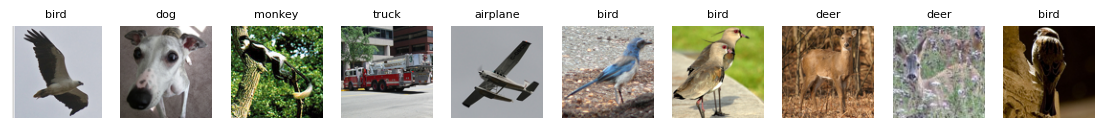

In [67]:
# визуализация картинок
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.savefig("artifacts/figures/augmentations_preview.png")
    plt.show()

show_images(train_loader, n=10)

In [68]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", save=False) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save: plt.savefig("artifacts/figures/classification_curves_best.png")
    plt.show()

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(96, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 12 * 12, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
    
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))
     


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6912, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable params: 951146


In [69]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, train_loader: DataLoader, 
                   val_loader: DataLoader, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"experiment_id": exp_id, "history": hist, "best_val_acc": best_val_acc}


def save_results(res: dict, file="artifacts/runs.csv"):
    fieldnames = [
        "experiment_id", "task", "dataset", "seed", "model_summary", "optimizer", "lr",
        "epochs_trained", "best_val_accuracy", "test_accuracy", "precision", "recall", "mean_iou", "notes"
    ]

    file_exists = os.path.isfile(file)

    with open(file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()
        
        writer.writerow(res)


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 951146
Epoch 01/12 | train loss 2.0193, acc 0.242 | val loss 1.6881, acc 0.385 | 6.7s
Epoch 02/12 | train loss 1.5635, acc 0.418 | val loss 1.5654, acc 0.411 | 5.5s
Epoch 03/12 | train loss 1.3568, acc 0.506 | val loss 1.3557, acc 0.502 | 5.6s
Epoch 04/12 | train loss 1.1036, acc 0.605 | val loss 1.3466, acc 0.508 | 5.6s
Epoch 05/12 | train loss 0.8718, acc 0.687 | val loss 1.2676, acc 0.548 | 5.6s
Epoch 06/12 | train loss 0.6500, acc 0.773 | val loss 1.5111, acc 0.535 | 5.6s
Epoch 07/12 | train loss 0.4323, acc 0.853 | val loss 1.7456, acc 0.527 | 5.6s
Epoch 08/12 | train loss 0.3002, acc 0.893 | val loss 1.8568, acc 0.509 | 6.0s
Epoch 09/12 | train loss 0.1620, acc 0.953 | val loss 2.2412, acc 0.532 | 5.7s
Epoch 10/12 | train loss 0.1063, acc 0.966 | val loss 2.4190, acc 0.512 | 5.7s
Epoch 11/12 | train loss 0.0781, acc 0.975 | val loss 3.0123, acc 0.477 | 5.7s
Epoch 12/12 | train loss 0.0492, acc 0.986 | val loss

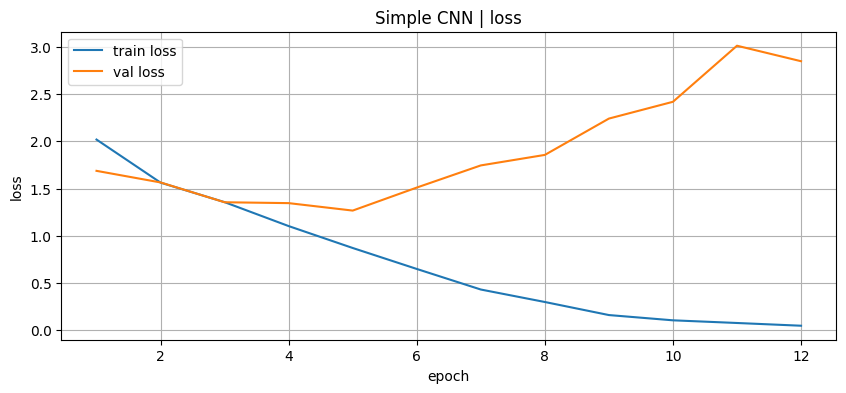

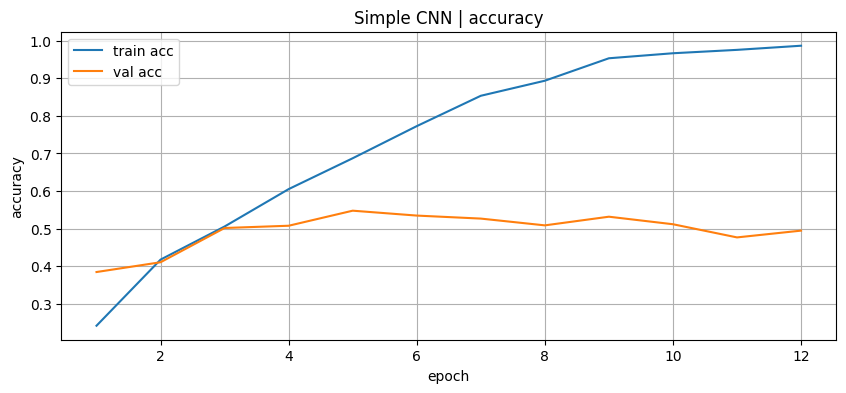

In [9]:
experiment_id = "C1"
model_name= "Simple CNN"
lr = 1e-3
epochs = EPOCHS

train_loader, val_loader, test_loader = make_loaders(*load_stl10("base"))
res_cnn = run_experiment(experiment_id, SimpleCNN(NUM_CLASSES), train_loader=train_loader, val_loader=val_loader, lr=lr, epochs=EPOCHS)
c1_val_acc = res_cnn["best_val_acc"]
plot_history(res_cnn["history"], title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "3 conv blocks, 2 classification layers",
    "optimizer": "Adam", 
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_accuracy": c1_val_acc,
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})


Experiment C2 | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 951146
Epoch 01/12 | train loss 2.0707, acc 0.235 | val loss 1.7628, acc 0.374 | 5.6s
Epoch 02/12 | train loss 1.6928, acc 0.370 | val loss 1.5184, acc 0.417 | 5.8s
Epoch 03/12 | train loss 1.5145, acc 0.441 | val loss 1.4292, acc 0.476 | 5.8s
Epoch 04/12 | train loss 1.4115, acc 0.477 | val loss 1.3203, acc 0.533 | 5.7s
Epoch 05/12 | train loss 1.2791, acc 0.523 | val loss 1.2625, acc 0.533 | 5.6s
Epoch 06/12 | train loss 1.2115, acc 0.550 | val loss 1.2753, acc 0.544 | 5.7s
Epoch 07/12 | train loss 1.1837, acc 0.569 | val loss 1.1611, acc 0.579 | 5.7s
Epoch 08/12 | train loss 1.1074, acc 0.593 | val loss 1.2406, acc 0.571 | 5.7s
Epoch 09/12 | train loss 1.0722, acc 0.603 | val loss 1.2021, acc 0.582 | 5.7s
Epoch 10/12 | train loss 1.0104, acc 0.629 | val loss 1.2387, acc 0.572 | 5.7s
Epoch 11/12 | train loss 0.9672, acc 0.653 | val loss 1.1243, acc 0.600 | 5.8s
Epoch 12/12 | train loss 0.9126, acc 0.671 | val loss

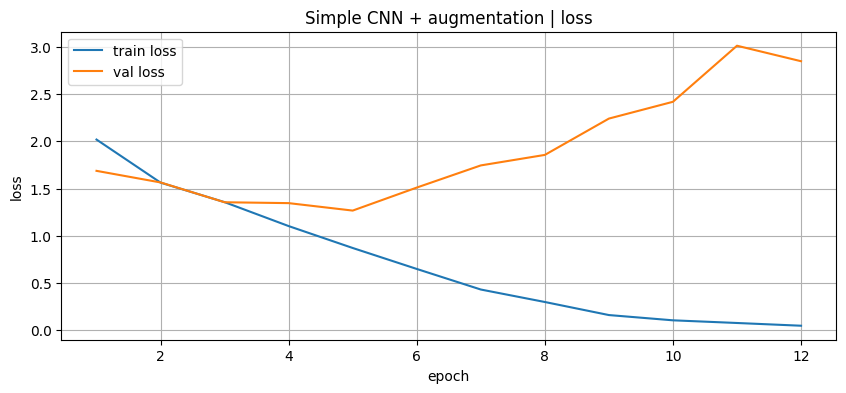

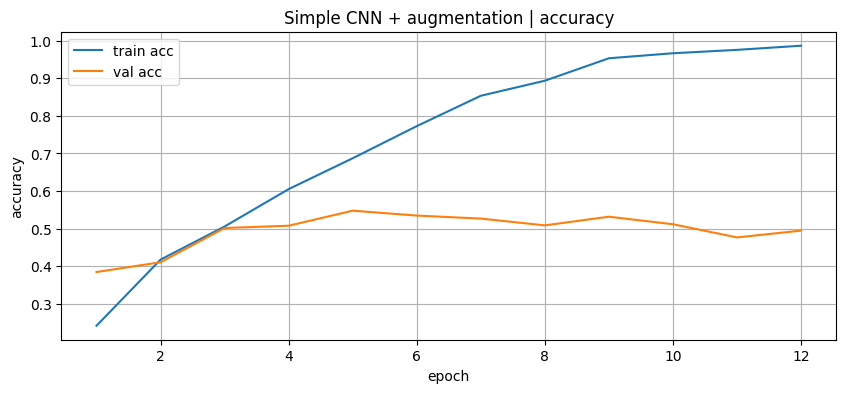

In [10]:
experiment_id = "C2"
model_name= "Simple CNN + augmentation"
lr = 1e-3
epochs = EPOCHS

train_loader, val_loader, test_loader = make_loaders(*load_stl10("aug"))
res_cnn_aug = run_experiment(experiment_id, SimpleCNN(NUM_CLASSES), train_loader=train_loader, val_loader=val_loader, lr=lr, epochs=EPOCHS)
c2_val_acc = res_cnn_aug["best_val_acc"]
plot_history(res_cnn["history"], title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "3 conv blocks, 2 classification layers",
    "optimizer": "Adam", 
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_accuracy": c2_val_acc,
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})

In [11]:

from torchvision.models import resnet18, ResNet18_Weights


def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [12]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/6 | train loss 1.3015, acc 0.654 | val loss 0.6000, acc 0.888 | 10.7s
Epoch 02/6 | train loss 0.4685, acc 0.919 | val loss 0.3526, acc 0.924 | 10.5s
Epoch 03/6 | train loss 0.3258, acc 0.935 | val loss 0.2731, acc 0.931 | 10.4s
Epoch 04/6 | train loss 0.2631, acc 0.944 | val loss 0.2387, acc 0.936 | 10.6s
Epoch 05/6 | train loss 0.2345, acc 0.945 | val loss 0.2145, acc 0.943 | 10.4s
Epoch 06/6 | train loss 0.2021, acc 0.953 | val loss 0.2016, acc 0.938 | 10.5s


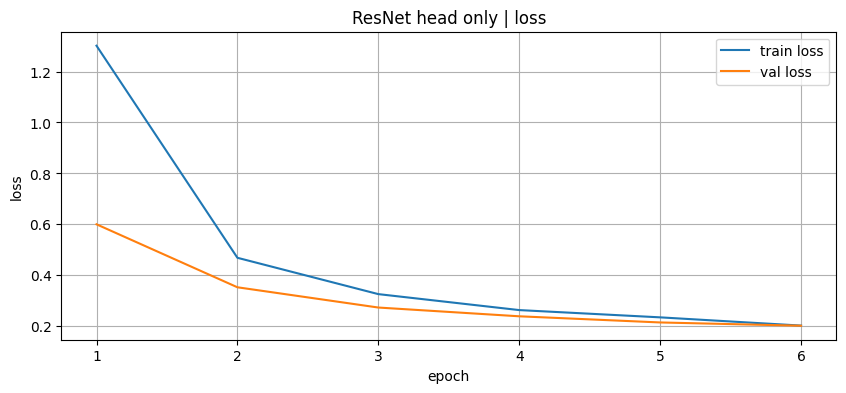

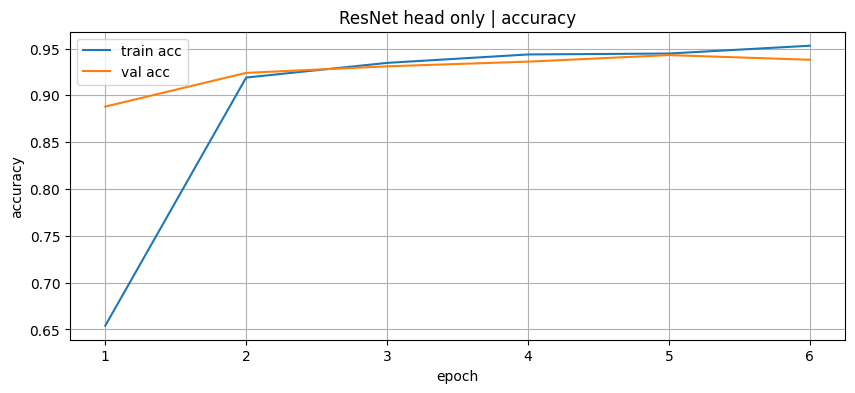

In [13]:
experiment_id = "C3"
model_name= "ResNet head only"
epochs = 6
lr = 1e-3

criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=lr)
train_loader, val_loader, test_loader = make_loaders(*load_stl10("resnet"))

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=epochs, verbose=True)
c3_val_acc = max(hist_head["val_acc"])
plot_history(hist_head, title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "ResNet18",
    "optimizer": "Adam", 
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_accuracy": c3_val_acc,
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})

In [14]:
experiment_id = "C4"
model_name= "ResNet18 | fine-tune layer4+fc"
epochs = 6

# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=epochs, verbose=True)
c4_val_acc = max(hist_ft["val_acc"])


Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/6 | train loss 0.1755, acc 0.947 | val loss 0.1410, acc 0.951 | 12.7s
Epoch 02/6 | train loss 0.0262, acc 0.997 | val loss 0.1146, acc 0.958 | 12.4s
Epoch 03/6 | train loss 0.0072, acc 1.000 | val loss 0.1192, acc 0.960 | 12.5s
Epoch 04/6 | train loss 0.0042, acc 1.000 | val loss 0.1051, acc 0.964 | 12.3s
Epoch 05/6 | train loss 0.0024, acc 1.000 | val loss 0.1037, acc 0.961 | 12.4s
Epoch 06/6 | train loss 0.0019, acc 1.000 | val loss 0.0985, acc 0.964 | 12.3s


Лучшей моделью в части А оказалась модель С4, поэтому для нее считаем accuracy на test

Accuracy = 0.949


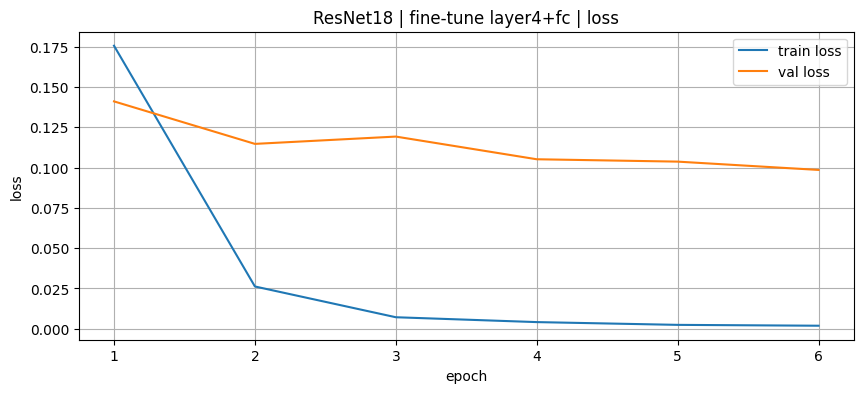

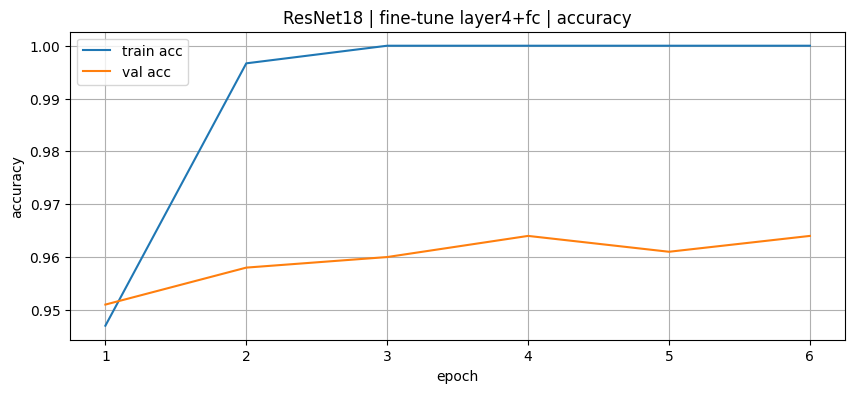

In [15]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

c4_test_acc = accuracy_on_loader(model_head, test_loader)
print(f"Accuracy = {c4_test_acc}")

plot_history(hist_ft, title=model_name, save=True)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "ResNet18 + fine-tune layer4+fc",
    "optimizer": "Adam", 
    "lr": "",
    "epochs_trained": epochs,
    "best_val_accuracy": c4_val_acc,
    "test_accuracy": c4_test_acc, 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})

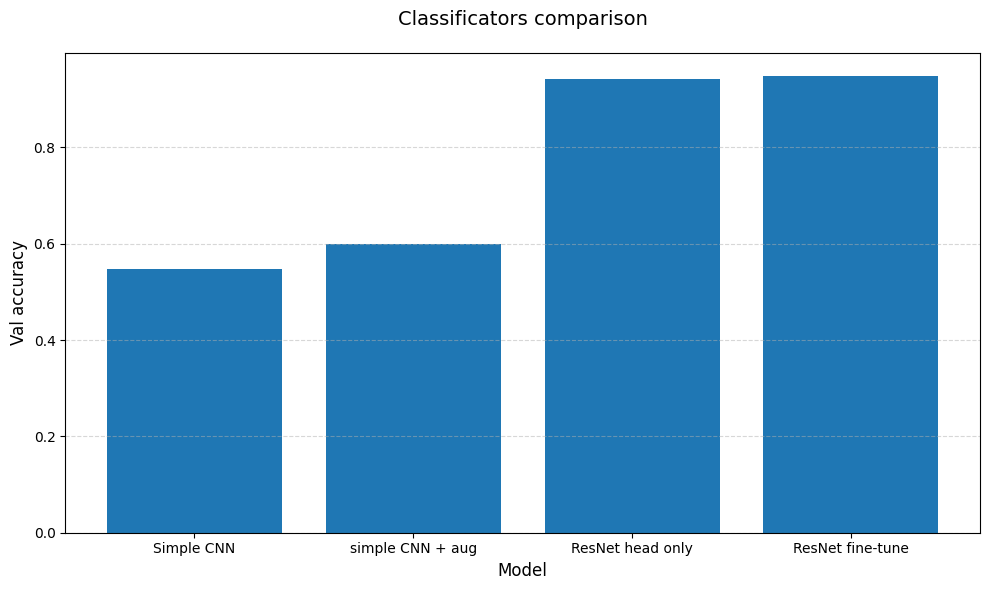

In [22]:
# Сохраняем артефакты части А

import json

torch.save(model_head.state_dict(), "artifacts/best_classifier.pt")

best_config = {
    "seed": RANDOM_STATE,
    "dataset": "STL10",
    "architecture": "ResNet18",
    "transforms": {
        "Resize": 256,
        "CenterCrop": 224,
        "Normalize": ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    },
    "optimizer": "Adam",
    "weight_decay": 1e-4,
    "epochs_trained": 6
}

with open("artifacts/best_config.json", 'w', encoding="utf-8") as f:
    json.dump(best_config, f, indent=4)


plt.figure(figsize=(10, 6))
bars = plt.bar(["Simple CNN", "simple CNN + aug", "ResNet head only", "ResNet fine-tune"],
                [c1_val_acc, c2_val_acc, c3_val_acc, c4_test_acc])

# Оформление
plt.xlabel('Model', fontsize=12)
plt.ylabel('Val accuracy', fontsize=12)
plt.title('Classificators comparison', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

# Часть B

In [53]:
from dataclasses import dataclass, field

import matplotlib.patches as patches

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

@dataclass
class RunConfig:
    data_dir: str = "./data"          # папка для скачивания VOC
    n_show: int = 4                   # сколько изображений визуализируем на режим
    iou_thr: float = 0.5              # порог IoU для TP/FP/FN
    eval_limit: int = 200             # сколько картинок берём для eval (None = все)
    score_thresholds: List[float] = field(default_factory=lambda: [0.3, 0.7])  # два режима
    model_name: str = "fasterrcnn_resnet50_fpn_v2"

cfg = RunConfig()

# Pascal VOC 20 классов (строки из XML-аннотаций)
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

# COCO 91-класс (индекс 0 = background, 1 = person, ...)
# Оставляем только пересечение VOC ∩ COCO (все 20 классов VOC есть в COCO)
COCO_CATEGORIES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

# Вручную составим таблицу соответствия VOC name → COCO index
# (некоторые названия слегка отличаются)
_VOC_TO_COCO_NAME = {
    "aeroplane":    "airplane",
    "bicycle":      "bicycle",
    "bird":         "bird",
    "boat":         "boat",
    "bottle":       "bottle",
    "bus":          "bus",
    "car":          "car",
    "cat":          "cat",
    "chair":        "chair",
    "cow":          "cow",
    "diningtable":  "dining table",
    "dog":          "dog",
    "horse":        "horse",
    "motorbike":    "motorcycle",
    "person":       "person",
    "pottedplant":  "potted plant",
    "sheep":        "sheep",
    "sofa":         "couch",
    "train":        "train",
    "tvmonitor":    "tv",
}

def voc_name_to_coco_idx(voc_name: str) -> Optional[int]:
    """Конвертируем VOC-название класса в COCO-индекс (или None если не нашлось)."""
    coco_name = _VOC_TO_COCO_NAME.get(voc_name)
    if coco_name is None:
        return None
    try:
        return COCO_CATEGORIES.index(coco_name)
    except ValueError:
        return None

# Валидный набор COCO-индексов, которые встречаются в VOC
VALID_COCO_INDICES = set(
    idx for idx in [voc_name_to_coco_idx(v) for v in VOC_CLASSES]
    if idx is not None
)

print(f"VOC классов: {len(VOC_CLASSES)}")
print(f"Найдено COCO-индексов для VOC классов: {len(VALID_COCO_INDICES)}")
print(f"Пример: 'person' → {voc_name_to_coco_idx('person')}, 'aeroplane' → {voc_name_to_coco_idx('aeroplane')}")

torch: 2.10.0+cu126
torchvision: 0.25.0+cu126
device: cuda
VOC классов: 20
Найдено COCO-индексов для VOC классов: 20
Пример: 'person' → 1, 'aeroplane' → 5


In [54]:
from torchvision.datasets import VOCDetection

print("Загружаем Pascal VOC 2007 test split...")
voc_dataset = VOCDetection(
    root=cfg.data_dir,
    year="2007",
    image_set="test",
    download=True,
    transform=transforms.ToTensor()
)

print(f"Всего изображений: {len(voc_dataset)}")

# Посмотрим на структуру одной аннотации
sample_img, sample_ann = voc_dataset[0]
print("\nТип изображения:", type(sample_img), "shape:", sample_img.shape)
print("\nСтруктура аннотации (верхний уровень):")
for k, v in sample_ann['annotation'].items():
    print(f"  {k}: {str(v)[:80]}")

Загружаем Pascal VOC 2007 test split...
Всего изображений: 4952

Тип изображения: <class 'torch.Tensor'> shape: torch.Size([3, 500, 353])

Структура аннотации (верхний уровень):
  folder: VOC2007
  filename: 000001.jpg
  source: {'database': 'The VOC2007 Database', 'annotation': 'PASCAL VOC2007', 'image': 'f
  owner: {'flickrid': 'Fried Camels', 'name': 'Jinky the Fruit Bat'}
  size: {'width': '353', 'height': '500', 'depth': '3'}
  segmented: 0
  object: [{'name': 'dog', 'pose': 'Left', 'truncated': '1', 'difficult': '0', 'bndbox': {


In [55]:
def parse_voc_annotation(ann: dict) -> Tuple[torch.Tensor, List[str]]:
    """
    Извлекаем bbox-ы и имена классов из VOC-аннотации.
    
    Возвращает:
        boxes  : Tensor[N, 4] в формате (x1, y1, x2, y2)
        names  : List[str]  — VOC-имена классов длиной N
    """
    objects = ann["annotation"].get("object", [])
    # VOCDetection может вернуть одиночный объект как dict, а не list
    if isinstance(objects, dict):
        objects = [objects]

    boxes = []
    names = []
    for obj in objects:
        name = obj["name"]  # 'person', 'car', ...
        bndbox = obj["bndbox"]
        x1 = float(bndbox["xmin"])
        y1 = float(bndbox["ymin"])
        x2 = float(bndbox["xmax"])
        y2 = float(bndbox["ymax"])
        boxes.append([x1, y1, x2, y2])
        names.append(name)

    if len(boxes) == 0:
        return torch.zeros((0, 4), dtype=torch.float32), []

    return torch.tensor(boxes, dtype=torch.float32), names


# Проверяем парсер на первом примере
gt_boxes, gt_names = parse_voc_annotation(sample_ann)
print("GT boxes:")
for b, n in zip(gt_boxes, gt_names):
    print(f"  {n}: {b.tolist()}")

GT boxes:
  dog: [48.0, 240.0, 195.0, 371.0]
  person: [8.0, 12.0, 352.0, 498.0]


In [57]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)

print(f"Загружаем модель: {cfg.model_name}")
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
model.to(DEVICE)
model.eval()

print(f"Классов в модели: {len(weights.meta['categories'])}")
print(f"Примеры классов: {weights.meta['categories']}")

Загружаем модель: fasterrcnn_resnet50_fpn_v2
Классов в модели: 91
Примеры классов: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy be

In [58]:
@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    """Инференс одного изображения, возвращает словарь на CPU."""
    out = model([img_t.to(DEVICE)])[0]
    return {k: v.detach().cpu() for k, v in out.items()}


def filter_preds(
    pred: Dict[str, torch.Tensor],
    score_thr: float,
    valid_coco_indices: Optional[set] = None
) -> Dict[str, torch.Tensor]:
    """
    Фильтруем предсказания:
    1) по score >= score_thr
    2) оставляем только классы, которые присутствуют в VOC (если valid_coco_indices задан)
    """
    keep = pred["scores"] >= score_thr
    if valid_coco_indices is not None:
        label_mask = torch.tensor(
            [int(l.item()) in valid_coco_indices for l in pred["labels"]],
            dtype=torch.bool
        )
        keep = keep & label_mask
    return {k: v[keep] for k, v in pred.items()}


def draw_boxes_on_ax(
    ax,
    boxes: torch.Tensor,
    color: str = "red",
    linewidth: float = 2,
    labels: Optional[List[str]] = None,
    alpha: float = 0.8
):
    """Рисуем прямоугольники на matplotlib-оси."""
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = b.tolist()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=linewidth, edgecolor=color, facecolor="none", alpha=alpha
        )
        ax.add_patch(rect)
        if labels is not None and i < len(labels):
            ax.text(
                x1, max(y1 - 3, 0), labels[i],
                color=color, fontsize=8, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=1)
            )


def tensor_to_rgb(img_t: torch.Tensor) -> np.ndarray:
    """[C,H,W] float → [H,W,3] uint8."""
    return (img_t.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)


def coco_idx_to_name(idx: int) -> str:
    if 0 <= idx < len(COCO_CATEGORIES):
        return COCO_CATEGORIES[idx]
    return str(idx)

In [59]:
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    """
    Вычисляем матрицу IoU между двумя наборами боксов.
    boxes: [N,4] и [M,4] в формате (x1,y1,x2,y2).
    Возвращает матрицу [N,M].
    """
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)
    union = area1[:, None] + area2[None, :] - inter + 1e-9

    return inter / union


def match_greedy(
    pred_boxes: torch.Tensor,
    pred_scores: torch.Tensor,
    gt_boxes: torch.Tensor,
    iou_thr: float
) -> Tuple[int, int, int, float]:
    """
    Жадное сопоставление: сортируем предсказания по убыванию score,
    каждое prediction матчим к лучшему ещё не занятому GT.

    ВАЖНО: это class-agnostic matching — проверяем только bbox overlap,
    не проверяем совпадение класса.

    Возвращает:
        TP, FP, FN, mean_IoU (по матчам)
    """
    n_gt = gt_boxes.shape[0]

    if pred_boxes.numel() == 0:
        return 0, 0, n_gt, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P, G]
    gt_used = torch.zeros(n_gt, dtype=torch.bool)

    tp, fp = 0, 0
    matched_ious = []

    for p in range(pred_boxes.shape[0]):
        if n_gt == 0:
            fp += 1
            continue
        best_iou_val, best_g = iou[p].max(dim=0)
        best_iou_val = float(best_iou_val.item())
        best_g = int(best_g.item())

        if best_iou_val >= iou_thr and not gt_used[best_g]:
            tp += 1
            gt_used[best_g] = True
            matched_ious.append(best_iou_val)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(matched_ious)) if matched_ious else float("nan")
    return tp, fp, fn, mean_iou


def evaluate_dataset(
    indices: List[int],
    score_thr: float
) -> Dict[str, float]:
    """
    Прогоняем инференс по subset датасета с данным score_thr.
    Возвращаем агрегированные метрики.
    """
    tps = fps = fns = 0
    all_ious = []

    for idx in indices:
        img_t, ann = voc_dataset[idx]
        gt_boxes, gt_names = parse_voc_annotation(ann)

        pred = predict_one(img_t)
        pred_f = filter_preds(pred, score_thr, VALID_COCO_INDICES)

        tp, fp, fn, miou = match_greedy(
            pred_f["boxes"], pred_f["scores"], gt_boxes, cfg.iou_thr
        )
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            all_ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall    = tps / (tps + fns + 1e-9)
    mean_iou  = float(np.mean(all_ious)) if all_ious else float("nan")

    return {
        "score_thr": score_thr,
        "TP": tps,
        "FP": fps,
        "FN": fns,
        "precision": precision,
        "recall": recall,
        "mean_IoU": mean_iou,
    }

In [92]:
from matplotlib.lines import Line2D


def run_inference_on_indices(
    indices: List[int],
    score_thr: float,
) -> List[Dict]:
    """
    Прогоняем модель на указанных индексах датасета при заданном score_thr.

    Параметры
    ----------
    indices   : список индексов из voc_dataset
    score_thr : порог уверенности — отбрасываем предсказания ниже этого значения

    Возвращает
    ----------
    List[Dict] — один словарь на каждое изображение:
        {
          'idx'        : int           — индекс в датасете
          'img_t'      : Tensor[C,H,W] — исходное изображение
          'gt_boxes'   : Tensor[N,4]   — ground-truth боксы
          'gt_names'   : List[str]     — VOC-имена GT-объектов
          'pred_boxes' : Tensor[M,4]   — отфильтрованные предсказанные боксы
          'pred_scores': Tensor[M]     — score каждого предсказания
          'pred_labels': List[str]     — читаемые метки вида 'класс:score'
        }
    """
    records = []
    for idx in indices:
        img_t, ann = voc_dataset[idx]
        gt_boxes, gt_names = parse_voc_annotation(ann)

        # Сырой вывод модели → фильтрация по score и классам VOC
        raw_pred = predict_one(img_t)
        pred_f   = filter_preds(raw_pred, score_thr, VALID_COCO_INDICES)

        # Читаемые метки: «имя_класса:score»
        pred_label_strs = [
            f"{coco_idx_to_name(int(lbl.item()))}:{float(sc.item()):.2f}"
            for lbl, sc in zip(pred_f["labels"], pred_f["scores"])
        ]

        records.append({
            "idx":         idx,
            "img_t":       img_t,
            "gt_boxes":    gt_boxes,
            "gt_names":    gt_names,
            "pred_boxes":  pred_f["boxes"],
            "pred_scores": pred_f["scores"],
            "pred_labels": pred_label_strs,
        })
    return records


def visualize_inference_results(
    records: List[Dict],
    score_thr: float,
    pred_color: str = "red",
    title_prefix: str = "",
    save=False
) -> None:
    """
    Рисует сетку изображений с GT-боксами (зелёный) и предсказаниями.

    Параметры
    ----------
    records      : результат run_inference_on_indices
    score_thr    : используется только для подписей на графике
    pred_color   : цвет предсказанных боксов
    title_prefix : префикс заголовка окна (например 'V1' или 'V2')
    """
    n = len(records)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, rec in zip(axes, records):
        ax.imshow(tensor_to_rgb(rec["img_t"]))
        ax.set_title(f"idx={rec['idx']} | thr={score_thr}", fontsize=10)
        ax.axis("off")

        # Ground Truth — всегда зелёный
        draw_boxes_on_ax(ax, rec["gt_boxes"],
                         color="lime", linewidth=2.5, labels=rec["gt_names"])

        # Предсказания — цвет задаётся снаружи
        draw_boxes_on_ax(ax, rec["pred_boxes"],
                         color=pred_color, linewidth=1.5, labels=rec["pred_labels"])

        ax.set_xlabel(
            f"GT: {rec['gt_boxes'].shape[0]}  Pred: {rec['pred_boxes'].shape[0]}",
            fontsize=9
        )

    fig.legend(
        handles=[
            Line2D([0], [0], color="lime",     linewidth=2.5, label="Ground Truth"),
            Line2D([0], [0], color=pred_color, linewidth=1.5,
                   label=f"Prediction (thr={score_thr})"),
        ],
        loc="lower center", ncol=2, fontsize=10
    )
    fig.suptitle(
        f"{title_prefix}: score_threshold = {score_thr}  "
        f"(зелёный = GT, {pred_color} = Pred)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    if save: plt.savefig("artifacts/figures/detection_examples.png")
    plt.show()

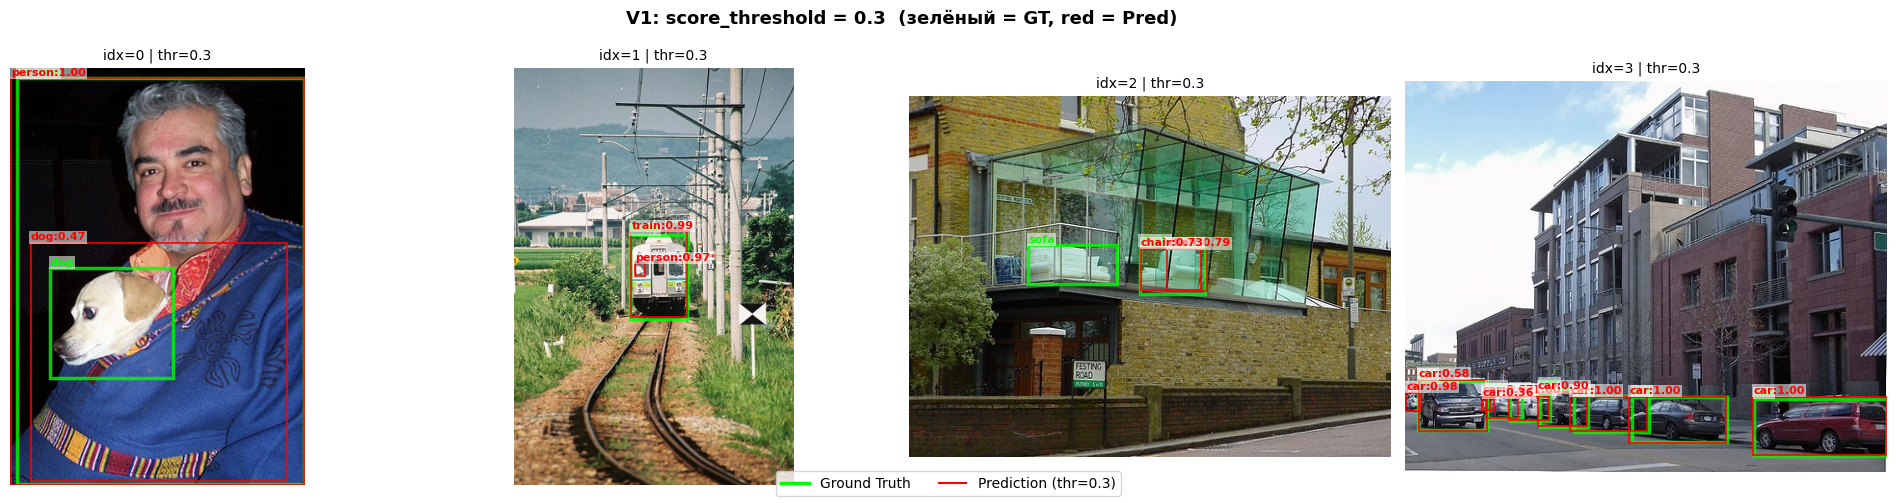

{'score_thr': 0.3, 'TP': 581, 'FP': 733, 'FN': 46, 'precision': 0.4421613394212769, 'recall': 0.926634768738554, 'mean_IoU': 0.8624642456281615}


In [93]:
vis_indices = list(range(min(cfg.n_show, len(voc_dataset))))

experiment_id = "V1"
score_thr = 0.3

records_v1 = run_inference_on_indices(vis_indices, score_thr=score_thr)
visualize_inference_results(records_v1, score_thr=score_thr, pred_color="red", title_prefix=experiment_id, save=True)

# Берём первые eval_limit изображений (или всё, если None)
if cfg.eval_limit is not None:
    eval_indices = list(range(min(cfg.eval_limit, len(voc_dataset))))
else:
    eval_indices = list(range(len(voc_dataset)))

metrics_v1 = evaluate_dataset(eval_indices, score_thr)
print(metrics_v1)
save_results({
    "experiment_id": experiment_id, 
    "task": "detection",
    "dataset": "Pascal VOC",
    "seed": RANDOM_STATE,
    "model_summary": "FasterRCNN_ResNet50_FPN_V2 inference",
    "optimizer": "", 
    "lr": "",
    "epochs_trained": "",
    "best_val_accuracy": "",
    "test_accuracy": "", 
    "precision": round(metrics_v1["precision"], 3), 
    "recall": round(metrics_v1["recall"], 3), 
    "mean_iou": round(metrics_v1["mean_IoU"], 3), 
    "notes": "threshold = 0.3, inference"
})


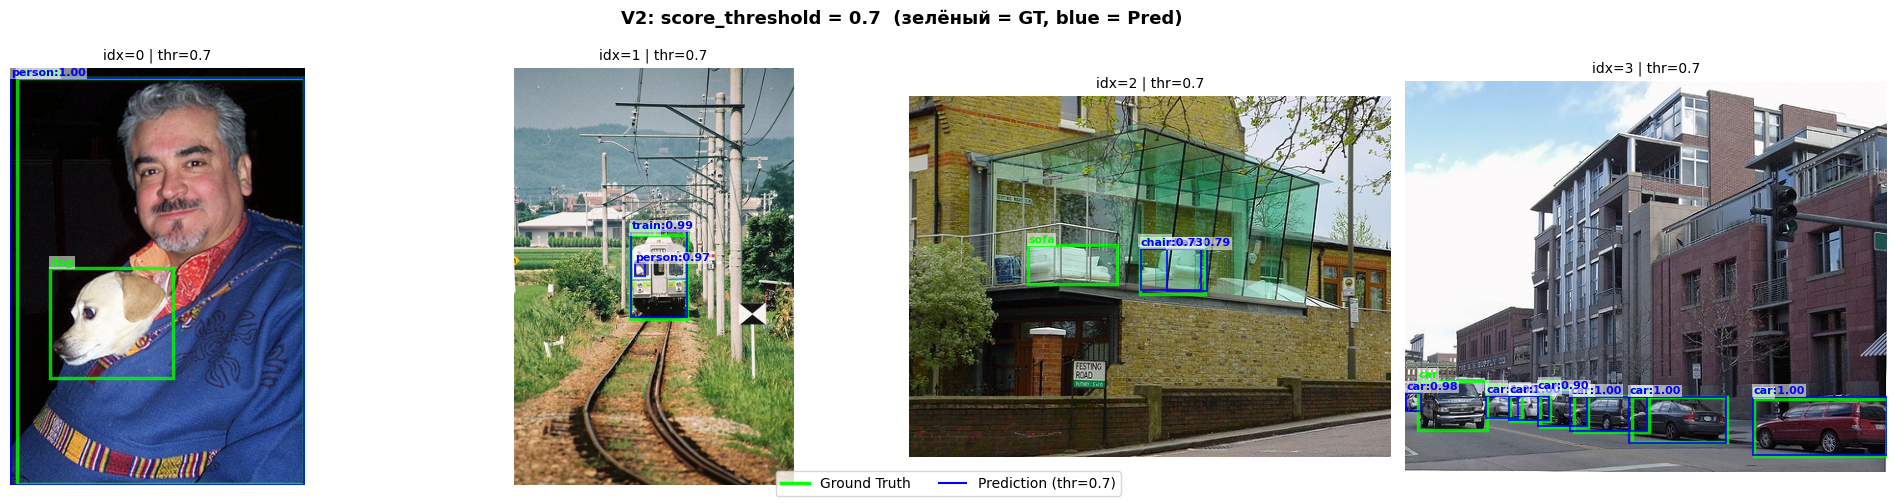

{'score_thr': 0.7, 'TP': 540, 'FP': 260, 'FN': 87, 'precision': 0.6749999999991563, 'recall': 0.8612440191373824, 'mean_IoU': 0.8654406972153886}


In [71]:
experiment_id = "V2"
score_thr = 0.7

records_v2 = run_inference_on_indices(vis_indices, score_thr=score_thr)
visualize_inference_results(records_v2, score_thr=score_thr, pred_color="blue", title_prefix=experiment_id)

metrics_v2 = evaluate_dataset(eval_indices, score_thr)
print(metrics_v2)
save_results({
    "experiment_id": experiment_id, 
    "task": "detection",
    "dataset": "Pascal VOC",
    "seed": RANDOM_STATE,
    "model_summary": "FasterRCNN_ResNet50_FPN_V2 inference",
    "optimizer": "", 
    "lr": "",
    "epochs_trained": "",
    "best_val_accuracy": "",
    "test_accuracy": "", 
    "precision": round(metrics_v2["precision"], 3), 
    "recall": round(metrics_v2["recall"], 3), 
    "mean_iou": round(metrics_v2["mean_IoU"], 3), 
    "notes": "threshold = 0.7, inference"
})

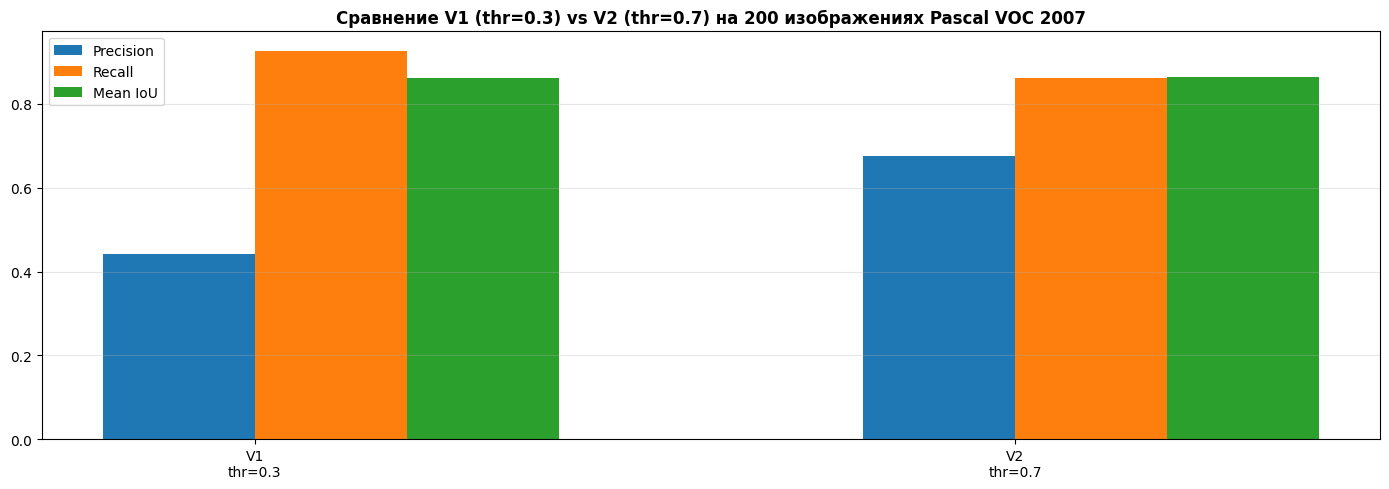

In [91]:
def compare_metrics(m1: Dict[str, float], m2: Dict[str, float]) -> None:
    thr1, thr2 = m1["score_thr"], m2["score_thr"]
    x_labels = [f"V1\nthr={thr1}", f"V2\nthr={thr2}"]
    x = np.arange(2)

    fig, ax = plt.subplots(1,1, figsize=(14, 5))


    bw2 = 0.2
    prec = [m1["precision"], m2["precision"]]
    rec  = [m1["recall"],    m2["recall"]]
    iou = [m1["mean_IoU"], m2["mean_IoU"]]
    ax.bar(x - bw2 / 2, prec, bw2, label="Precision")
    ax.bar(x + bw2 / 2 , rec,  bw2, label="Recall")
    ax.bar(x + 3 * bw2 / 2, iou,  bw2, label="Mean IoU")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_title(f"Сравнение V1 (thr={thr1}) vs V2 (thr={thr2}) "
        f"на {len(eval_indices)} изображениях Pascal VOC 2007",
        fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("artifacts/figures/detection_metrics.png")
    plt.show()


compare_metrics(metrics_v1, metrics_v2)